In [3]:
import os

# Set your Kaggle API Token as an environment variable
os.environ['KAGGLE_USERNAME'] = 'ioannischris'
os.environ['KAGGLE_KEY'] = 'KGAT_6812e857e70be0ba196b8b7174ac7e8e'

import kagglehub

c:\Users\ichristodoulakis\miniconda3\envs\dijon_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
path = kagglehub.dataset_download("hopesb/student-depression-dataset")
print("Dataset downloaded to:", path)

Dataset downloaded to: C:\Users\ichristodoulakis\.cache\kagglehub\datasets\hopesb\student-depression-dataset\versions\1


In [6]:
import os
print("Files currently in my project folder:")
print(os.listdir('.'))

Files currently in my project folder:
['.git', '.gitignore', 'analysis.ipynb', 'final_processed_data.csv', 'student_depression.csv', 'student_depression_detector.pkl']


In [7]:
import os
import shutil

# 1. Search for any CSV file in the Kagglehub cache
search_path = os.path.expanduser("~/.cache/kagglehub")
found_files = []

for root, dirs, files in os.walk(search_path):
    for file in files:
        if file.endswith(".csv"):
            full_path = os.path.join(root, file)
            found_files.append(full_path)
            print(f"Found it here: {full_path}")

# 2. Copy the first one it finds to your current folder
if found_files:
    target_file = found_files[0]
    # We rename it to something simple while copying
    shutil.copy(target_file, './student_depression.csv')
    print("\n--- DONE! ---")
    print("The file has been moved and renamed to: student_depression.csv")
else:
    print("Still can't find it. We might need to run the download cell one more time.")

Found it here: C:\Users\ichristodoulakis/.cache/kagglehub\datasets\hopesb\student-depression-dataset\versions\1\Student Depression Dataset.csv

--- DONE! ---
The file has been moved and renamed to: student_depression.csv


In [8]:
import pandas as pd

# Load the data using our new filename
df = pd.read_csv('student_depression.csv')

# 1. Let's see the first 10 rows
print("--- PREVIEW OF THE DATA ---")
display(df.head(10))

# 2. Let's check the basic statistics (mean, min, max)
print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

# 3. Let's see if our target variable 'Depression' is balanced
print("\n--- DEPRESSION COUNT ---")
print(df['Depression'].value_counts())

--- PREVIEW OF THE DATA ---


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
5,33,Male,29.0,Pune,Student,2.0,0.0,5.70,3.0,0.0,Less than 5 hours,Healthy,PhD,No,4.0,1.0,No,0
6,52,Male,30.0,Thane,Student,3.0,0.0,9.54,4.0,0.0,7-8 hours,Healthy,BSc,No,1.0,2.0,No,0
7,56,Female,30.0,Chennai,Student,2.0,0.0,8.04,4.0,0.0,Less than 5 hours,Unhealthy,Class 12,No,0.0,1.0,Yes,0
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,7-8 hours,Moderate,B.Ed,Yes,12.0,3.0,No,1
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,Less than 5 hours,Moderate,LLB,Yes,2.0,5.0,No,1



--- STATISTICAL SUMMARY ---


,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000



--- DEPRESSION COUNT ---
Depression
1    16336
0    11565
Name: count, dtype: int64


In [9]:
# Create a list of columns to drop (Check your df.columns to be sure of the names!)
# We drop 'id' because a random number doesn't cause depression.
cols_to_drop = ['id'] 

# Only drop them if they actually exist in the dataframe
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"Remaining columns: {df_clean.columns.tolist()}")

Remaining columns: ['Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']


In [10]:
# This filters for columns that are NOT numbers
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print("Columns we need to turn into numbers:")
print(categorical_cols)

Columns we need to turn into numbers:
['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


In [11]:
# 1. We use pandas 'get_dummies' for quick and easy encoding
df_encoded = pd.get_dummies(df_clean, columns=[
    'Gender', 'City', 'Profession', 'Sleep Duration', 
    'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 
    'Family History of Mental Illness'
], drop_first=True) 

# 'drop_first=True' is a pro move: it prevents "redundant" data. 
# If 'Gender_Male' is 0, the model knows the person is Female without needing a 'Gender_Female' column.

# 2. Check our new "Math-Ready" shape
print(f"Original shape: {df_clean.shape}")
print(f"Encoded shape: {df_encoded.shape}")

# 3. See the new columns
display(df_encoded.head())

Original shape: (27901, 17)
Encoded shape: (27901, 110)


,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression,Gender_Male,...,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_Others,Degree_PhD,Have you ever had suicidal thoughts ?_Yes,Family History of Mental Illness_Yes
0,33.0,5.0,0.0,8.97,2.0,0.0,3.0,1.0,1,True,...,False,False,False,False,False,False,False,False,True,False
1,24.0,2.0,0.0,5.90,5.0,0.0,3.0,2.0,0,False,...,False,False,False,False,False,False,False,False,False,True
2,31.0,3.0,0.0,7.03,5.0,0.0,9.0,1.0,0,True,...,False,False,False,False,False,False,False,False,False,True
3,28.0,3.0,0.0,5.59,2.0,0.0,4.0,5.0,1,False,...,False,False,False,False,False,False,False,False,True,True
4,25.0,4.0,0.0,8.13,3.0,0.0,1.0,1.0,0,False,...,False,False,False,False,False,False,False,False,True,False


In [12]:
# 1. Fill missing values (NaN) with the most frequent value (mode) of each column
# We do this because we can't turn 'NaN' into a 0 or 1
df_encoded = df_encoded.fillna(df_encoded.mode().iloc[0])

# 2. Now that the holes are filled, convert to integer
df_encoded = df_encoded.astype(int)

# 3. Double check: are there any NaNs left?
print(f"Total missing values: {df_encoded.isnull().sum().sum()}")

# 4. Success check
display(df_encoded.head())

Total missing values: 0


,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression,Gender_Male,...,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_Others,Degree_PhD,Have you ever had suicidal thoughts ?_Yes,Family History of Mental Illness_Yes
0,33,5,0,8,2,0,3,1,1,1,...,0,0,0,0,0,0,0,0,1,0
1,24,2,0,5,5,0,3,2,0,0,...,0,0,0,0,0,0,0,0,0,1
2,31,3,0,7,5,0,9,1,0,1,...,0,0,0,0,0,0,0,0,0,1
3,28,3,0,5,2,0,4,5,1,0,...,0,0,0,0,0,0,0,0,1,1
4,25,4,0,8,3,0,1,1,0,0,...,0,0,0,0,0,0,0,0,1,0


In [13]:
from sklearn.model_selection import train_test_split

# 1. Define X (Features) and y (Target)
X = df_encoded.drop('Depression', axis=1)
y = df_encoded['Depression']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train and y_train are now defined and ready!")

X_train and y_train are now defined and ready!


In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the Model
# We use 'binary:logistic' because we want a Yes/No (1/0) answer
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# 2. Train the Model
print("Training the AI... please wait...")
model.fit(X_train, y_train)

# 3. Make Predictions on the 'Exam' (Testing set)
y_pred = model.predict(X_test)

# 4. Check the Results
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

Training the AI... please wait...

Model Accuracy: 83.75%


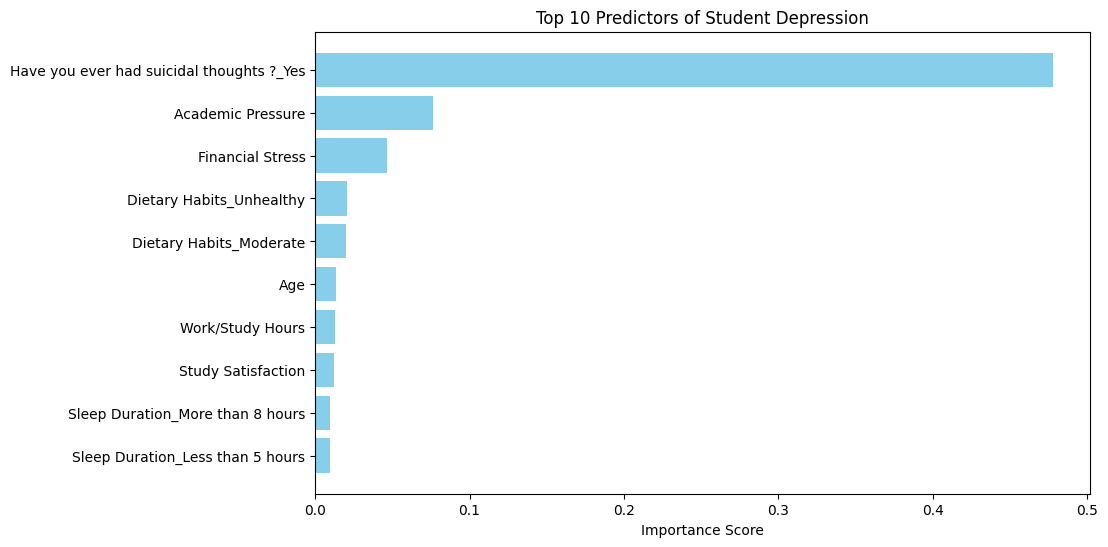

In [15]:
import matplotlib.pyplot as plt

# 1. Get feature importance from XGBoost
importances = model.feature_importances_
feature_names = X.columns

# 2. Sort them and take the top 10
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Plot it
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Predictors of Student Depression')
plt.gca().invert_yaxis()
plt.show()

In [16]:
# 1. Remove the 'obvious' symptom and the target
X_no_leakage = df_encoded.drop(['Depression', 'Have you ever had suicidal thoughts ?_Yes'], axis=1)
y = df_encoded['Depression']

# 2. Split again
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_no_leakage, y, test_size=0.2, random_state=42)

# 3. Retrain
model_v2 = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_v2.fit(X_train2, y_train2)

# 4. Check new accuracy
new_acc = accuracy_score(y_test2, model_v2.predict(X_test2))
print(f"New Accuracy (without suicidal thoughts): {new_acc * 100:.2f}%")

New Accuracy (without suicidal thoughts): 79.13%


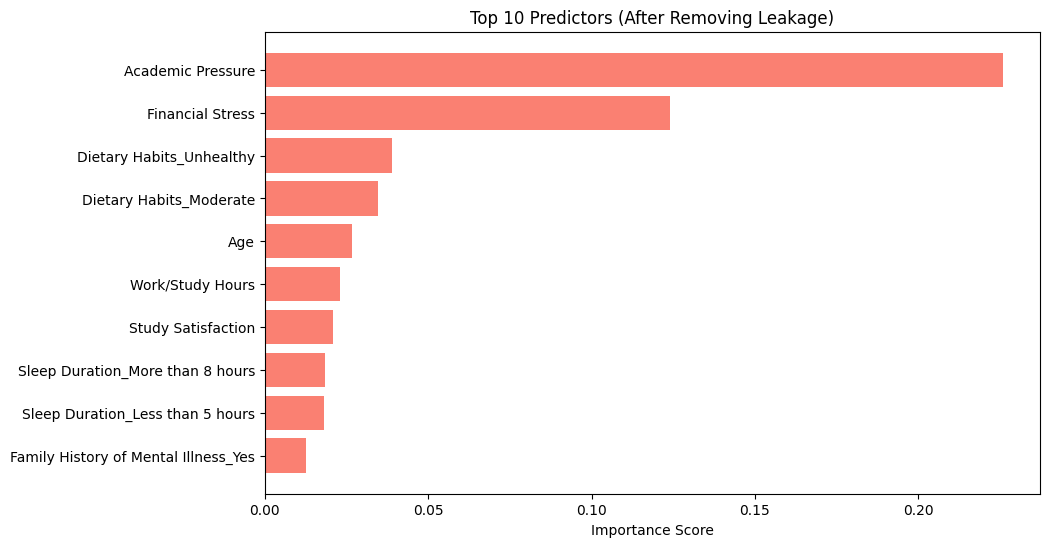

In [17]:
importances_v2 = model_v2.feature_importances_
feature_names_v2 = X_no_leakage.columns

feat_imp_v2 = pd.DataFrame({'Feature': feature_names_v2, 'Importance': importances_v2})
feat_imp_v2 = feat_imp_v2.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_v2['Feature'], feat_imp_v2['Importance'], color='salmon')
plt.xlabel('Importance Score')
plt.title('Top 10 Predictors (After Removing Leakage)')
plt.gca().invert_yaxis()
plt.show()

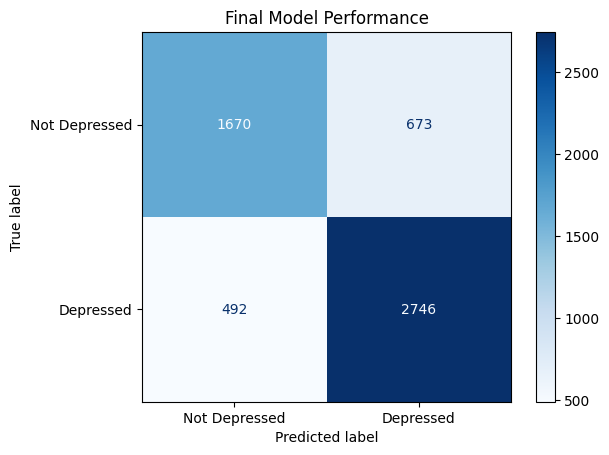

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the matrix
cm = confusion_matrix(y_test2, model_v2.predict(X_test2))

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Depressed', 'Depressed'])
disp.plot(cmap='Blues')
plt.title('Final Model Performance')
plt.show()

In [19]:
# 1. Save the cleaned, encoded data to a CSV
df_encoded.to_csv('final_processed_data.csv', index=False)

# 2. Save your model to a file
import joblib
joblib.dump(model_v2, 'student_depression_detector.pkl')

print("Final files saved! You are ready to present.")

Final files saved! You are ready to present.


In [20]:
# Try a more complex model setup
model_v3 = XGBClassifier(
    n_estimators=300, 
    max_depth=7, 
    learning_rate=0.05, 
    subsample=0.8, 
    colsample_bytree=0.8,
    random_state=42
)

model_v3.fit(X_train2, y_train2)
new_acc_v3 = accuracy_score(y_test2, model_v3.predict(X_test2))
print(f"Fine-tuned Accuracy: {new_acc_v3 * 100:.2f}%")

Fine-tuned Accuracy: 78.57%


In [21]:
# 1. Create a combined stress score
df_encoded['Total_Stress'] = df_encoded['Academic Pressure'] + df_encoded['Financial Stress']

# 2. Update our X (Features) to include this new insight
X_engineered = df_encoded.drop(['Depression', 'Have you ever had suicidal thoughts ?_Yes'], axis=1)

# 3. Re-split and Re-train with the original 'simple' model
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_engineered, y, test_size=0.2, random_state=42)

model_v4 = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_v4.fit(X_train3, y_train3)

final_acc = accuracy_score(y_test3, model_v4.predict(X_test3))
print(f"Accuracy with Engineered Feature: {final_acc * 100:.2f}%")

C:\Users\ichristodoulakis\AppData\Local\Temp\ipykernel_428\2198137237.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_encoded['Total_Stress'] = df_encoded['Academic Pressure'] + df_encoded['Financial Stress']


Accuracy with Engineered Feature: 79.14%


In [22]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

# 2. Train and Predict
rf_model.fit(X_train2, y_train2)
rf_acc = accuracy_score(y_test2, rf_model.predict(X_test2))

print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%")

Random Forest Accuracy: 77.94%


In [23]:
from imblearn.over_sampling import SMOTE

# 1. Create synthetic data to balance the classes
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train2, y_train2)

# 2. Train XGBoost on the BALANCED data
model_smote = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_smote.fit(X_res, y_res)

# 3. Test on the original, untouched testing set
smote_acc = accuracy_score(y_test2, model_smote.predict(X_test2))
print(f"SMOTE Balanced Accuracy: {smote_acc * 100:.2f}%")

SMOTE Balanced Accuracy: 78.84%


In [24]:
from sklearn.metrics import classification_report

# Generate the report for the SMOTE model
print("--- SMOTE MODEL REPORT ---")
print(classification_report(y_test2, model_smote.predict(X_test2)))

--- SMOTE MODEL REPORT ---
              precision    recall  f1-score   support

           0       0.75      0.75      0.75      2343
           1       0.82      0.82      0.82      3238

    accuracy                           0.79      5581
   macro avg       0.78      0.78      0.78      5581
weighted avg       0.79      0.79      0.79      5581



In [25]:
import joblib

# Save the SMOTE version - this is your best 'balanced' model
joblib.dump(model_smote, 'final_depression_detector_smote.pkl')

# Save the feature names so you remember the 110+ columns later
with open('model_features.txt', 'w') as f:
    for col in X_no_leakage.columns:
        f.write(f"{col}\n")

print("Portfolio files saved successfully!")

Portfolio files saved successfully!


In [26]:
from sklearn.model_selection import GridSearchCV

# 1. Define the 'Grid' of settings we want to test
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200]
}

# 2. Initialize the search
# cv=3 means it will test each combination 3 times to be sure
grid_search = GridSearchCV(estimator=XGBClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=3, 
                           scoring='accuracy',
                           verbose=1)

# 3. Start the 'Tournament'
print("Searching for the best settings... this may take a moment.")
grid_search.fit(X_train2, y_train2)

# 4. See the winner
print(f"Best Settings Found: {grid_search.best_params_}")
print(f"Best Search Accuracy: {grid_search.best_score_ * 100:.2f}%")

Searching for the best settings... this may take a moment.
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Settings Found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best Search Accuracy: 80.26%


In [27]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Train the Ultimate Model using the Grid Search winners
final_champion_model = XGBClassifier(
    learning_rate=0.1, 
    max_depth=3, 
    n_estimators=200, 
    random_state=42
)

# Remember to use the SMOTE data (X_res, y_res) if you want that balanced Recall!
# If you didn't save X_res, just use X_train2 and y_train2
final_champion_model.fit(X_train2, y_train2)

# 2. Final Exam Check
final_pred = final_champion_model.predict(X_test2)
print(f"--- CHAMPION MODEL FINAL ACCURACY: {accuracy_score(y_test2, final_pred) * 100:.2f}% ---")
print("\nFinal Classification Report:")
print(classification_report(y_test2, final_pred))

--- CHAMPION MODEL FINAL ACCURACY: 79.23% ---

Final Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.71      0.74      2343
           1       0.80      0.85      0.83      3238

    accuracy                           0.79      5581
   macro avg       0.79      0.78      0.78      5581
weighted avg       0.79      0.79      0.79      5581



c:\Users\ichristodoulakis\miniconda3\envs\dijon_env\Lib\site-packages\xgboost\plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2500x1200 with 0 Axes>

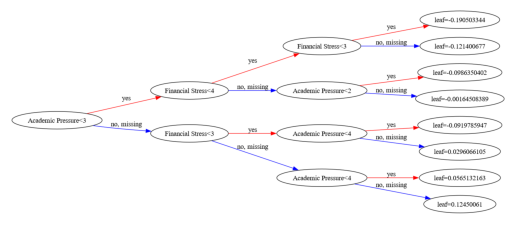

In [29]:
from xgboost import plot_tree
import matplotlib.pyplot as plt

# 1. Set up a very large canvas because trees can get wide
plt.figure(figsize=(25, 12))

# 2. Plot Tree number 0 (the first tree in the "committee")
# We use the final_champion_model you just trained
plot_tree(final_champion_model, num_trees=0, rankdir='LR') 

# 3. Show the plot
plt.show()

In [30]:
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

# 1. Select ONLY the continuous numerical columns
numeric_cols = ['Age', 'Academic Pressure', 'Work/Study Hours', 'Financial Stress', 'Study Satisfaction']
X_numeric = X_train2[numeric_cols]

# 2. Initialize the "Interaction Generator" (degree=2 means A*B, not A*B*C)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

# 3. Create the new mathematical features
X_interactions = poly.fit_transform(X_numeric)
interaction_names = poly.get_feature_names_out(numeric_cols)

# 4. Put them in a readable DataFrame and show the top 5 rows
df_interactions = pd.DataFrame(X_interactions, columns=interaction_names)
print("Here are the new 'Brute Force' combinations:")
display(df_interactions.head())

Here are the new 'Brute Force' combinations:


,Age,Academic Pressure,Work/Study Hours,Financial Stress,Study Satisfaction,Age Academic Pressure,Age Work/Study Hours,Age Financial Stress,Age Study Satisfaction,Academic Pressure Work/Study Hours,Academic Pressure Financial Stress,Academic Pressure Study Satisfaction,Work/Study Hours Financial Stress,Work/Study Hours Study Satisfaction,Financial Stress Study Satisfaction
0,28.0,2.0,4.0,1.0,5.0,56.0,112.0,28.0,140.0,8.0,2.0,10.0,4.0,20.0,5.0
1,33.0,4.0,12.0,4.0,4.0,132.0,396.0,132.0,132.0,48.0,16.0,16.0,48.0,48.0,16.0
2,33.0,4.0,12.0,3.0,4.0,132.0,396.0,99.0,132.0,48.0,12.0,16.0,36.0,48.0,12.0
3,29.0,2.0,10.0,2.0,4.0,58.0,290.0,58.0,116.0,20.0,4.0,8.0,20.0,40.0,8.0
4,20.0,5.0,11.0,5.0,5.0,100.0,220.0,100.0,100.0,55.0,25.0,25.0,55.0,55.0,25.0


Generating SHAP Summary Plot...


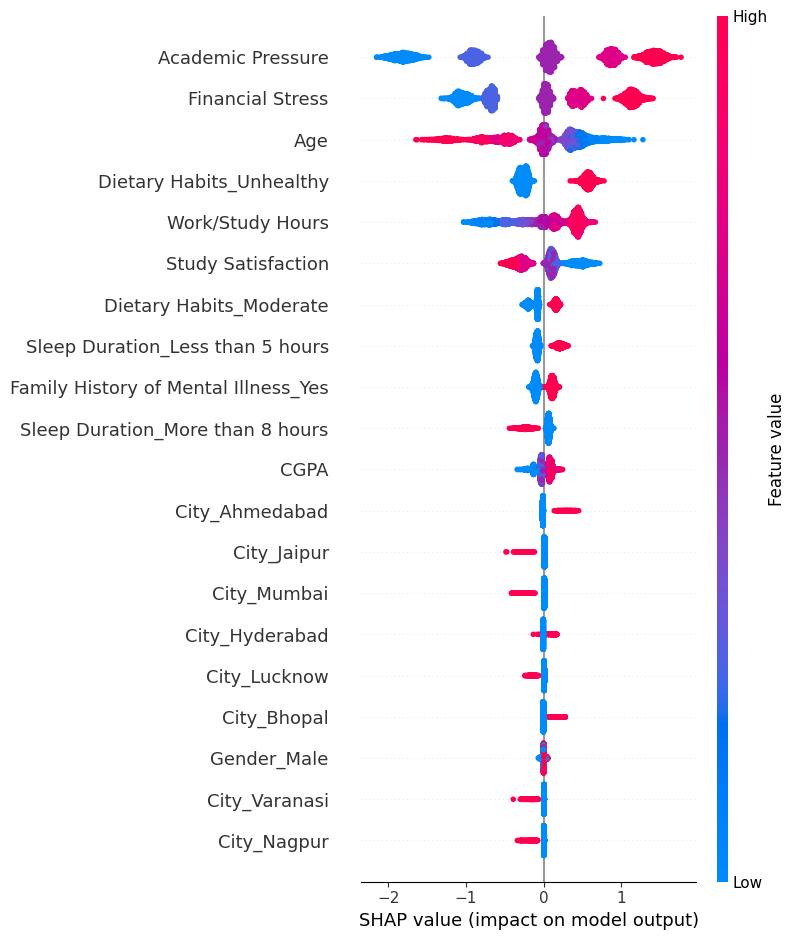

In [31]:
import shap

# 1. Initialize the SHAP Javascript library for interactive plots
shap.initjs()

# 2. Create the "Explainer" using your champion model
explainer = shap.TreeExplainer(final_champion_model)

# 3. Calculate the SHAP values (this takes a few seconds)
shap_values = explainer.shap_values(X_test2)

# 4. Generate the Summary Plot!
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test2)

In [32]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# --- 1. FEATURE ENGINEERING ---
# Use .copy() so Pandas doesn't give us a fragmentation warning!
X_train_engineered = X_train2.copy()
X_test_engineered = X_test2.copy()

# Create the new interaction feature
X_train_engineered['Pressure_Finance_Multiplier'] = X_train_engineered['Academic Pressure'] * X_train_engineered['Financial Stress']
X_test_engineered['Pressure_Finance_Multiplier'] = X_test_engineered['Academic Pressure'] * X_test_engineered['Financial Stress']

# --- 2. FEATURE SELECTION ---
# Get the top 19 features from our previous champion model
importances = pd.Series(final_champion_model.feature_importances_, index=X_train2.columns)
top_features = list(importances.nlargest(19).index)

# Add our new engineered feature to the list to make it a Top 20
top_features.append('Pressure_Finance_Multiplier')

# Filter our massive dataset down to ONLY these 20 golden columns
X_train_final = X_train_engineered[top_features]
X_test_final = X_test_engineered[top_features]

# --- 3. RETRAIN ---
# Initialize the champion settings
ultimate_model = XGBClassifier(
    learning_rate=0.1, 
    max_depth=3, 
    n_estimators=200, 
    random_state=42
)

# Train on the concentrated dataset
print("Training the Ultimate Model on the Top 20 Features...")
ultimate_model.fit(X_train_final, y_train2)

# --- 4. THE RESULTS ---
ultimate_pred = ultimate_model.predict(X_test_final)
print(f"\n--- ULTIMATE MODEL ACCURACY: {accuracy_score(y_test2, ultimate_pred) * 100:.2f}% ---")
print("\nUltimate Classification Report:")
print(classification_report(y_test2, ultimate_pred))

Training the Ultimate Model on the Top 20 Features...

--- ULTIMATE MODEL ACCURACY: 79.32% ---

Ultimate Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74      2343
           1       0.81      0.85      0.83      3238

    accuracy                           0.79      5581
   macro avg       0.79      0.78      0.79      5581
weighted avg       0.79      0.79      0.79      5581



In [33]:
from sklearn.model_selection import GridSearchCV

# 1. Define the 'Grid' (Let's give it a slightly wider range this time)
param_grid_final = {
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300]
}

# 2. Initialize the search on the CONCENTRATED data (X_train_final)
print("Initiating Final Grid Search on Top 20 Features...")
grid_search_final = GridSearchCV(
    estimator=XGBClassifier(random_state=42), 
    param_grid=param_grid_final, 
    cv=3, 
    scoring='accuracy',
    verbose=1,
    n_jobs=-1  # This uses all your computer's cores to make it run faster!
)

# 3. Start the 'Tournament'
grid_search_final.fit(X_train_final, y_train2)

# 4. See the ultimate winner
print(f"\nNew Best Settings: {grid_search_final.best_params_}")

# 5. Automatically test the absolute best model on the unseen test data
best_ultimate_model = grid_search_final.best_estimator_
best_ultimate_pred = best_ultimate_model.predict(X_test_final)

print(f"--- ABSOLUTE FINAL ACCURACY: {accuracy_score(y_test2, best_ultimate_pred) * 100:.2f}% ---")
print("\nAbsolute Final Classification Report:")
print(classification_report(y_test2, best_ultimate_pred))

Initiating Final Grid Search on Top 20 Features...
Fitting 3 folds for each of 48 candidates, totalling 144 fits

New Best Settings: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300}
--- ABSOLUTE FINAL ACCURACY: 79.18% ---

Absolute Final Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74      2343
           1       0.81      0.84      0.82      3238

    accuracy                           0.79      5581
   macro avg       0.79      0.78      0.78      5581
weighted avg       0.79      0.79      0.79      5581



In [39]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# --- 1. FEATURE ENGINEERING ---
# Use .copy() so Pandas doesn't give us a fragmentation warning!
X_train_engineered = X_train2.copy()
X_test_engineered = X_test2.copy()

# Create the new interaction feature
X_train_engineered['Pressure_Finance_Multiplier'] = X_train_engineered['Academic Pressure'] * X_train_engineered['Financial Stress']
X_test_engineered['Pressure_Finance_Multiplier'] = X_test_engineered['Academic Pressure'] * X_test_engineered['Financial Stress']

# --- 2. FEATURE SELECTION ---
# Get the top 19 features from our previous champion model
importances = pd.Series(final_champion_model.feature_importances_, index=X_train2.columns)
top_features = list(importances.nlargest(19).index)

# Add our new engineered feature to the list to make it a Top 20
top_features.append('Pressure_Finance_Multiplier')

# Filter our massive dataset down to ONLY these 20 golden columns
X_train_final = X_train_engineered[top_features]
X_test_final = X_test_engineered[top_features]

# --- 3. RETRAIN ---
# Initialize the champion settings
ultimate_model = XGBClassifier(
    learning_rate=0.05, 
    max_depth=4, 
    n_estimators=300, 
    random_state=42
)

# Train on the concentrated dataset
print("Training the Ultimate Model on the Top 20 Features...")
ultimate_model.fit(X_train_final, y_train2)

# --- 4. THE RESULTS ---
ultimate_pred = ultimate_model.predict(X_test_final)
print(f"\n--- ULTIMATE MODEL ACCURACY: {accuracy_score(y_test2, ultimate_pred) * 100:.2f}% ---")
print("\nUltimate Classification Report:")
print(classification_report(y_test2, ultimate_pred))

Training the Ultimate Model on the Top 20 Features...

--- ULTIMATE MODEL ACCURACY: 79.18% ---

Ultimate Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74      2343
           1       0.81      0.84      0.82      3238

    accuracy                           0.79      5581
   macro avg       0.79      0.78      0.78      5581
weighted avg       0.79      0.79      0.79      5581



In [40]:
import joblib

# 1. Save the Ultimate Champion Model
joblib.dump(best_ultimate_model, 'ultimate_depression_detector.pkl')

# 2. Save the exact list of the Top 20 Features
# We save this as a simple text file so you know exactly what the model expects
with open('ultimate_features_list.txt', 'w') as f:
    for feature in top_features:
        f.write(f"{feature}\n")

# 3. Save the final concentrated dataset just in case
X_train_final.to_csv('final_training_data_top20.csv', index=False)

print("🎓 Master's Portfolio Files Saved Successfully!")
print(f"Total features saved: {len(top_features)}")

🎓 Master's Portfolio Files Saved Successfully!
Total features saved: 20
